In [1]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [2]:
"""
We read the table with all mutations
"""
df_flask = pd.read_excel('Biofilm_curated.xlsx', index_col=0)
df = pd.DataFrame(df_flask.Sample.value_counts())
df_single = df_flask.loc[df_flask.Sample.isin(df.loc[df['count'] == 1].index)]

#The following line saves the variants with no mutation 
df_single.loc[df_single.gene == 'No Mutation'][['Barcode']]#.to_csv('Neutral_barcodes.csv')

,Barcode
0,TTCACCTATTTTGTATCATTTATTTAGTAT
44,TTCTTAAATGTTGTATCTAATATAGATAAT
62,TTTTTCGATTTTTAATCTTTAATTGCCAAT
90,TTATGGGATTGCCGATTGCGGATTGCGGAT
92,TTGCTAGATGACCAATTAAATATTGGGTAT
...,...
82,TTGTATTATCTCTGATGGATTATCTCTGAT
90,TTTGGGAATTGTAAATAACTCATAGTTGAT
92,TTCGCTCATTAGCCATACGGTATTCAGCAT
93,TTGGTGCATATGGTATAACTCATGAACTAT


In [3]:
print("Numnber of unique barcodes sequenced:" + str(len(df_flask.Identified_Barcode.value_counts())))

Numnber of unique barcodes sequenced:106


In [4]:
#Here we extract all the barcodes with mutations in them
df_mutatedbarcodes = df_flask.loc[df_flask.gene != 'No Mutation']
len(df_mutatedbarcodes)

48

In [5]:
df_flask.Sample.drop_duplicates().str[0:1].value_counts()

Sample
E    48
D    39
C    19
Name: count, dtype: int64

In [6]:
pd.DataFrame(df_mutatedbarcodes.Sample.value_counts()).rename(columns = {'count':'Count'}).Count.value_counts()

Count
1    32
2     8
Name: count, dtype: int64

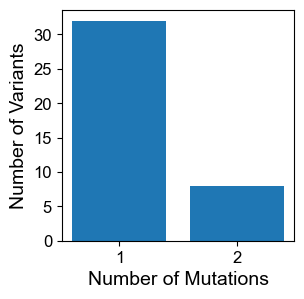

In [7]:
"""
The following code is to calculate the number of mutations per variant
"""
plt.figure(figsize = [3,3])
plt.bar([1,2],pd.DataFrame(df_mutatedbarcodes.Sample.value_counts()).rename(columns = {'count':'Count'}).Count.value_counts())
plt.xticks([1,2],[1,2],rotation = 0, fontname = 'Arial', fontsize = 12);
plt.yticks(rotation = 0, fontname = 'Arial', fontsize = 12);
plt.xlabel('Number of Mutations', fontname = 'Arial', fontsize = 14)
plt.ylabel('Number of Variants', fontname = 'Arial', fontsize = 14)
plt.savefig('Figures paper/mutationspervariant.svg', format = 'svg', dpi = 300)

In [8]:
df = pd.DataFrame(df_mutatedbarcodes.Sample.value_counts())
df_single = df_mutatedbarcodes.loc[df_mutatedbarcodes.Sample.isin(df.loc[df['count'] == 1].index)]
df_single

,Sample,Barcode,Identified_Barcode,Counts,Fitness,Population\nFrequency,Disk 1 Fre,Disk 2 Fre,position,mutation,annotation,Type,gene,description
2,C11,TTGCGCGATAATAAATTCTATATTGTCAAT,TTGCGCGATAATAAATTCTATATTGTCAAT,15.0,0.037565,2.532005,0.850760,1.126905,3529671,C→T,A145V (GCA→GTA),Non-synonymous,crp →,cAMP‑activated global transcriptional regulato...
20,C15,TTCCGGAATAGAACATTCGTTATTACCCAT,TTCCGGAATAGAACATTCGTTATTACCCAT,24.0,0.041243,24.323862,9.721662,5.879485,4667186,T→A,V77D (GTC→GAC),Non-synonymous,fimH →,type 1 fimbria D‑mannose specific adhesin FimH
45,C19,TTGTCGCATGCTCGATTAGCAATTACAAAT,TTGTCGCATGCTCGATTAGCAATTTCAAAT,3.0,0.051620,0.001429,0.000339,0.000596,4667326,T→C,W124R (TGG→CGG),Non-synonymous,fimH →,type 1 fimbria D‑mannose specific adhesin FimH
49,C22,TTTTATTATTCGGTATGGGAAATAAAGCAT,TTTTATTATTCGGTATGGGAAATAAAGCAT,7.0,0.037143,1.434747,0.199189,0.272728,3744301,C→T,H295Y (CAC→TAC),Non-synonymous,bcsG →,cellulose biosynthesis protein BcsG
56,C24,TTGACTGATTTCCAATTTTTCATATGCGAT,TTGACTGATTTCCAATTTTTCATATGCGAT,3.0,0.056013,1.930791,0.786935,0.841839,4667042,Δ36 bp,coding (86‑121/903 nt),Indel,fimH →,type 1 fimbria D‑mannose specific adhesin FimH
59,C25,TTCTAGCATAGTAGATCTTCGATTCGTCAT,TTCTAGCATAGTAGATCTTCGATTCGTCAT,3.0,0.064930,5.598028,2.408447,2.480530,4667042,Δ36 bp,coding (86‑121/903 nt),Indel,fimH →,type 1 fimbria D‑mannose specific adhesin FimH
63,C29,TTATGCGATATTTTATATCTAATTTCGAAT,TTATGCGATATTTTATATCTAATTTCGAAT,2.0,0.013682,1.037448,0.469993,0.787889,4037507,G→T,A401S (GCG→TCG),Non-synonymous,cyaA →,class I adenylate cyclase
65,C3,TTAGCATATCTGTGATGTAGTATAACATAT,TTAGCATATCTGTGATGTAGTATAACATAT,4.0,0.000000,1.893660,0.805902,0.624508,4667234,Δ15 bp,coding (278‑292/903 nt),Indel,fimH →,type 1 fimbria D‑mannose specific adhesin FimH
69,C30,TTTTTGAATCATTTATTTCATATATTCGAT,TTTTTGAATCATTTATTTCATATATTCGAT,1.0,0.048031,0.002602,0.000038,0.001560,2159109,A→C,intergenic (‑130/‑188),Intergenic,udk ← / → dgcE,uridine kinase/diguanylate cyclase
77,C50,TTAAATTATATGGTATCAGTGATAGAATAT,TTAAATTATATGGTATCAGTGATAGAATAT,1.0,0.042682,0.082150,0.005306,0.005418,3743656,T→C,W80R (TGG→CGG),Non-synonymous,bcsG →,cellulose biosynthesis protein BcsG


In [9]:
df_pergene = pd.DataFrame(df_single.loc[(df_single.Type != 'Synonymous') & \
                                                 (df_single.gene.str.find('aslA') < 0) & \
                                                (df_single.gene.str.find('LF82') < 0) &\
                                                (df_single.gene.str.find('Maybe') < 0)].gene.value_counts())
df_pergene.to_clipboard()

In [10]:
df_pergene = pd.DataFrame(df_mutatedbarcodes.loc[(df_mutatedbarcodes.Type != 'Synonymous') & \
                                                 (df_mutatedbarcodes.gene.str.find('aslA') < 0) & \
                                                (df_mutatedbarcodes.gene.str.find('LF82') < 0) &\
                                                (df_mutatedbarcodes.gene.str.find('Maybe') < 0)].gene.value_counts())
df_pergene.to_csv('Biofilm_MutByGene.csv')
plt.figure(figsize = [10,3])
df_pergene.sort_index()
#.gene.plot.bar()
df_pergene.to_clipboard()

<Figure size 1000x300 with 0 Axes>

In [11]:
df_mutatedbarcodes.loc[df_mutatedbarcodes.gene.str.find('crp') >= 0].Identified_Barcode.value_counts()

Identified_Barcode
TTGCGCGATAATAAATTCTATATTGTCAAT    1
TTCTTAGATTATCGATCAGTGATCGCGGAT    1
TTTTCATATAGTCTATAGTTCATTTAATAT    1
Name: count, dtype: int64

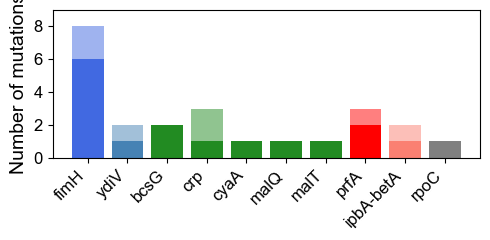

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load Data ---------------------------------------------------------------
df = pd.read_excel('Biofilm_Mutbygene.xlsx')

# --- Create pivot table -------------------------------------------------------
pivot = df.pivot_table(index="Gene", columns="Type",
                       values="Mutations", aggfunc="sum", fill_value=0)

# --- Extract base color per gene ---------------------------------------------
gene_color = df.groupby("Gene")["Color"].first()

# --- Custom gene ordering -----------------------------------------------------
custom_order = []

# 1. fimH block (royalblue)
blue_genes = gene_color[gene_color == "royalblue"].index.tolist()
custom_order.extend(blue_genes)

# 1. fimH block (royalblue)
blue_genes = gene_color[gene_color == "steelblue"].index.tolist()
custom_order.extend(blue_genes)

# 2. crp block (forestgreen)
green_genes = gene_color[gene_color == "forestgreen"].index.tolist()
custom_order.extend(green_genes)

# 3. prfA block (red)
red_genes = gene_color[gene_color == "red"].index.tolist()
custom_order.extend(red_genes)

# 4. ipbA-betA block (salmon)
salmon_genes = gene_color[gene_color == "salmon"].index.tolist()
custom_order.extend(salmon_genes)

# 5. yciB block (gray)
gray_genes = gene_color[gene_color == "gray"].index.tolist()
custom_order.extend(gray_genes)

# 5. yciB block (gray)
black_genes = gene_color[gene_color == "Orange"].index.tolist()
custom_order.extend(black_genes)

# Ensure order contains each gene once
ordered_genes = [g for g in custom_order if g in pivot.index]

# --- Prepare stacked bar values ----------------------------------------------
single_vals = pivot.loc[ordered_genes]["Single"] if "Single" in pivot else 0
multiple_vals = pivot.loc[ordered_genes]["Multiple"] if "Multiple" in pivot else 0

# --- Plot ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5,2.5))

# Draw single (solid)
ax.bar(
    ordered_genes,
    single_vals,
    color=[gene_color[g] for g in ordered_genes],
    label="Single"
)

# Draw multiple (alpha = 0.5)
ax.bar(
    ordered_genes,
    multiple_vals,
    bottom=single_vals,
    color=[gene_color[g] for g in ordered_genes],
    alpha=0.5,
    label="Multiple"
)

# Formatting
plt.xticks(rotation=45, ha="right",  fontname = 'arial', fontsize = 12)
plt.yticks(fontname = 'arial', fontsize = 12)

plt.ylabel("Number of mutations", fontname = 'arial', fontsize = 14)
plt.tight_layout()

plt.ylim([0,9])

#plt.show()

plt.savefig('Figures paper/mutationspergene.svg', format = 'svg', dpi = 300)

In [13]:
multiple_vals

Gene
fimH         2
ydiV         1
bcsG         0
crp          2
cyaA         0
malQ         0
malT         0
prfA         1
ipbA-betA    1
rpoC         0
Name: Multiple, dtype: int64

In [14]:
df_pergene

,count
gene,
fimH →,8
crp →,3
prfA →,3
bcsG →,2
ipbA ← / ← betA,2
atoS →,1
udk ← / → dgcE,1
cyaA →,1
[ydiV],1


In [16]:
"""
You can start the code from here
"""
#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090
